# The Physics and Engineering of an HTGR–Desalination Complex
### A Systems Textbook, Built Subsystem by Subsystem

**Source material:** Imperial College London / Rolls-Royce "Imperial Team 5" project report and final
presentation, *"Scaled High Temperature Test Reactor Cogeneration for Zero-Emission Hybrid
Desalination with Independent Water Heat Rejection"* (March 2026) — see [`reference/`](../reference/)
for the original PDF report and Simulink model.

**How this notebook is organized.** Each chapter introduces one subsystem, states its governing
equations exactly as given in the source material, and — wherever the underlying calculation is
simple enough to be self-contained — reproduces the worked numbers **live, in code, checked against
the report's own results**. Where a chapter's subsystem is implemented as working software elsewhere
in this repository (the point-kinetics/thermal-core physics engine), the chapter runs that actual,
tested code rather than a simplified stand-in.

A few numbers below don't quite agree between the report and the presentation slide deck; rather
than silently pick one, this notebook recomputes them from first principles and states which source
each one matches, in the same spirit as the [debug log](../README.md#engineering-debug-log) for the
rest of this repository.

| Part | Chapters | Subsystem |
|---|---|---|
| I | 1–5 | Reactor selection, point kinetics, thermal-hydraulics, validation |
| II | 6–8 | Coolant fluid mechanics, the combined Brayton–Rankine power cycle |
| III | 9–11 | Hybrid desalination, DEEP economics, CO₂ sustainability |
| IV | 12 | Reactor and plant safety systems |
| V | 13–15 | Independent water heat rejection: design, modelling, results |
| VI | 16–17 | System integration and conclusions |


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..").resolve()))

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.precision", 4)

---
# Part I — Reactor Selection and Core Physics

## Chapter 1 — Reactor Technology Down-Selection

The project's first design decision is *which* High-Temperature Gas-Cooled Reactor (HTGR) class to
build around. Three candidates were compared against the requirement of driving Multi-Effect
Distillation (MED) at scale while sustaining a daily population of 80,000 with freshwater:

In [2]:
downselect = pd.DataFrame({
    "Reactor Type": ["Pebble-Bed HTGR", "Micro-HTGR", "HTTR-Desalination (selected)"],
    "Thermal Power": ["200-300 MWth", "0.5-20 MWth", "300 MWth"],
    "Electrical Output": ["70-80 MWe", "0.1-5 MWe", "30-50 MWe"],
    "Outlet Temp.": ["750 C", "750 C", "950 C"],
    "Key Advantage": [
        "Proven architecture, industrial-scale output",
        "Very passive safety, portable/remote use",
        "950 C outlet ideal for high-efficiency MED/TVC",
    ],
    "Key Limitation": [
        "Not optimised for MED desalination",
        "Very small output, limited desalination capability",
        "Research-derived design",
    ],
})
downselect

,Reactor Type,Thermal Power,Electrical Output,Outlet Temp.,Key Advantage,Key Limitation
0,Pebble-Bed HTGR,200-300 MWth,70-80 MWe,750 C,"Proven architecture, industrial-scale output",Not optimised for MED desalination
1,Micro-HTGR,0.5-20 MWth,0.1-5 MWe,750 C,"Very passive safety, portable/remote use","Very small output, limited desalination capabi..."
2,HTTR-Desalination (selected),300 MWth,30-50 MWe,950 C,950 C outlet ideal for high-efficiency MED/TVC,Research-derived design


**Why 950 °C matters.** MED thermal efficiency (its Gain Output Ratio, GOR — see Chapter 9) climbs
with the temperature and quality of the driving steam. Only the HTTR-class design reaches 950 °C,
which is what makes it "uniquely bridge the gap between high-enthalpy power cycles and low-grade
thermal distillation" (report, §1.1) — the other two candidates top out at 750 °C.

### Why 300 MWth and not the real HTTR's ~30 MWth?

The actual High-Temperature Engineering Test Reactor (HTTR) this design scales from is a ~30 MWth
research reactor. The presentation deck (§4.4.3) gives the explicit reasoning for the 10× scale-up
to a 300 MWth "commercial/utility scale" design:

1. **Population demand.** A 30 MWth reactor produces only enough freshwater for roughly 8,000
   people. Serving the target city of 80,000/day requires scaling thermal power (and therefore
   water production) up by roughly the same factor.
2. **Economic viability.** The 27% IRR (Chapter 10) depends on economies of scale — a 30 MWth plant
   has a much higher cost per litre of water produced, because capital costs don't shrink
   proportionally with thermal power.

This scaling choice is why `src/htgr_physics.py`'s `KineticsParams.q_nominal = 300e6` (300 MWth) and
`OperatingConditions.helium_mass_flow = 105.0` kg/s (roughly 10× the real HTTR's 10.5–12.3 kg/s) are
what they are — not arbitrary round numbers, but a deliberate, reasoned 10× scale-up. It's also the
reason Chapter 5's validation plot doesn't share axes with this project's full operating point: the
literature benchmark data is for the *original* ~30 MWth HTTR, not the scaled 300 MWth design.

## Chapter 2 — Point Kinetics: The Physics of Neutron Population

Point kinetics describes how reactor power evolves in time due to neutron multiplication, without
tracking the spatial distribution of neutrons in the core — an excellent approximation for a
well-moderated, compact core like this one.

**Reactor power equation:**
$$\frac{dP(t)}{dt} = \left(\frac{\rho(t)-\beta}{\Lambda}\right)P(t) + \sum_{i=1}^{6}\lambda_i C_i(t)$$

**Delayed-neutron precursor groups** ($i = 1, \ldots, 6$):
$$\frac{dC_i(t)}{dt} = \left(\frac{\beta_i}{\Lambda}\right)P(t) - \lambda_i C_i(t)$$

| Symbol | Meaning | Value used |
|:---:|---|---|
| $P(t)$ | Normalised reactor power ($P=1$ at nominal) | — |
| $C_i(t)$ | Normalised precursor concentration, group $i$ | — |
| $\rho(t)$ | Total reactivity | scenario-dependent |
| $\beta$ | Total delayed-neutron fraction | 0.0075 |
| $\beta_i$ | Delayed-neutron fraction, group $i$ | [0.00025, 0.00138, 0.00122, 0.00266, 0.00164, 0.00035] |
| $\Lambda$ | Prompt neutron lifetime | $1.0\times10^{-3}$ s |
| $\lambda_i$ | Decay constant, group $i$ (s⁻¹) | [0.0766, 0.2825, 0.6154, 1.634, 5.176, 16.72] |
| $Q_{fission}$ | Thermal power, $= P(t)\cdot Q_{nominal}$ | $Q_{nominal}=300$ MWth |

Six precursor groups, rather than one, is what gives the reactor its characteristic **slow "memory"
effect** on power changes — some delayed neutrons appear tens of seconds after the fission that
produced their precursor, which is exactly what makes a reactor controllable on a human timescale
instead of the ~10⁻³ s prompt-neutron timescale alone.

In [3]:
from src.htgr_physics import KineticsParams

k = KineticsParams()
print(f"beta_total = {k.beta_total:.4f}")
print(f"Lambda     = {k.prompt_neutron_lifetime:.1e} s")
print(f"Q_nominal  = {k.q_nominal/1e6:.0f} MWth")
pd.DataFrame({"beta_i": k.beta_i, "lambda_i [1/s]": k.lambda_i,
              "precursor half-life [s]": np.log(2) / k.lambda_i},
             index=[f"Group {i+1}" for i in range(6)])

beta_total = 0.0075
Lambda     = 1.0e-03 s
Q_nominal  = 300 MWth


,beta_i,lambda_i [1/s],precursor half-life [s]
Group 1,0.0003,0.0766,9.0489
Group 2,0.0014,0.2825,2.4536
Group 3,0.0012,0.6154,1.1263
Group 4,0.0027,1.6340,0.4242
Group 5,0.0016,5.1760,0.1339
Group 6,0.0003,16.7200,0.0415


## Chapter 3 — Thermal-Hydraulics: The Three-Node Core Model

Fission heat has to get from the fuel, through the graphite moderator, into the helium coolant, and
out of the core. The report lumps this into three thermal nodes — fuel, moderator, coolant — each
with its own heat capacity, coupled by heat-transfer coefficients:

$$C_f\frac{dT_f}{dt} = Q_{fission} - h_{fm}(T_f-T_m) - h_{fc}(T_f-T_c)$$
$$C_m\frac{dT_m}{dt} = h_{fm}(T_f-T_m) - h_{mc}(T_m-T_c)$$
$$C_c\frac{dT_c}{dt} = h_{fc}(T_f-T_c) + h_{mc}(T_m-T_c) - 2\dot{m}C_p(T_c-T_{in})$$

| Symbol | Meaning | Value |
|:---:|---|---|
| $T_f$ | Average TRISO fuel-kernel temperature [K] | — |
| $T_m$ | Bulk graphite matrix temperature [K] | — |
| $T_c$ | Bulk helium coolant temperature [K] | — |
| $C_f, C_m, C_c$ | Thermal capacities ("heat mass", $m\cdot C_p$) | $5\times10^6$, $1\times10^8$, $1\times10^6$ J/K |
| $h_{fm}, h_{fc}, h_{mc}$ | Inter-node heat-transfer coefficients | $2\times10^5$, $4\times10^5$, $1.5\times10^5$ W/K |
| $\dot{m}$ | Helium mass flow rate | 105 kg/s (10× the real HTTR's 10.5–12.3 kg/s) |
| $T_{in}$ | Coolant inlet temperature | 350 °C (623.15 K) |
| $C_p$ | Helium specific heat | 5193 J/(kg·K) |

Notice the moderator's heat capacity ($10^8$ J/K) is roughly 20× the fuel's and 100× the coolant's —
graphite's enormous thermal mass is precisely the passive-safety feature the report leans on: it
smooths out fast reactivity transients into slow, controllable temperature drifts.

In [4]:
from src.htgr_physics import ThermalCoreParams, OperatingConditions

p = ThermalCoreParams()
op = OperatingConditions()
print(f"C_f={p.c_fuel:.1e} J/K   C_m={p.c_moderator:.1e} J/K   C_c={p.c_coolant:.1e} J/K")
print(f"h_fm={p.h_fuel_moderator:.1e}  h_fc={p.h_fuel_coolant:.1e}  h_mc={p.h_moderator_coolant:.1e}  [W/K]")
print(f"mdot={op.helium_mass_flow} kg/s   T_in={op.coolant_inlet_temp:.2f} K ({op.coolant_inlet_temp-273.15:.0f} C)")
print(f"time constant m/h_mc (moderator-coolant) ~ {p.c_moderator/p.h_moderator_coolant:.0f} s"
      f"  vs fuel/h_fc ~ {p.c_fuel/p.h_fuel_coolant:.1f} s")

C_f=5.0e+06 J/K   C_m=1.0e+08 J/K   C_c=1.0e+06 J/K
h_fm=2.0e+05  h_fc=4.0e+05  h_mc=1.5e+05  [W/K]
mdot=105.0 kg/s   T_in=623.15 K (350 C)
time constant m/h_mc (moderator-coolant) ~ 667 s  vs fuel/h_fc ~ 12.5 s


## Chapter 4 — Coupling Kinetics and Thermal-Hydraulics: A Live Demonstration

This is where theory becomes running code. `src/htgr_physics.py`'s `HTGRReactorModel` couples
Chapters 2 and 3 into one 10-state ODE system ($P, C_1..C_6, T_f, T_m, T_c$) and integrates it with
`scipy.integrate.solve_ivp`. Below, a small positive reactivity step is applied at $t=100$ s — the
same transient shape used for validation in the report's Fig. 3 — starting from the model's own
analytically-solved steady state (`steady_state()`, described in [Step 1's build log](../README.md)),
not a guessed initial condition.

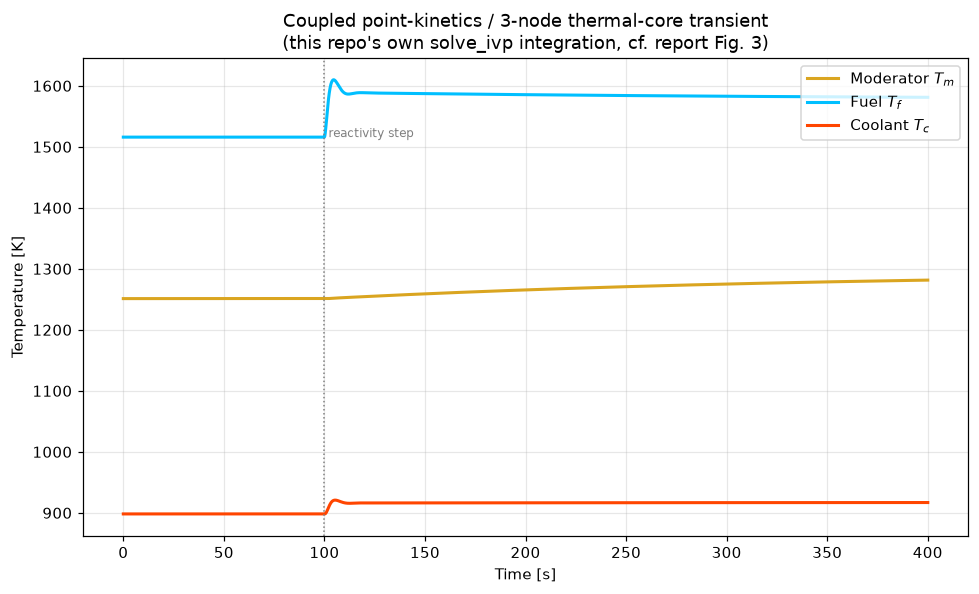

Steady state at t=0:   Tf=1515.9 K  Tm=1251.2 K  Tc=898.2 K
Peak after step:       Tf=1609.9 K  Tm=1281.5 K


In [5]:
from src.htgr_physics import HTGRReactorModel, doppler_feedback_reactivity

probe = HTGRReactorModel(reactivity=lambda t, tf, tm: 0.0)
y0 = probe.steady_state()

reactivity = doppler_feedback_reactivity(
    t_step=100.0, rho_insertion=0.0022,
    fuel_temp_ref=y0[7], moderator_temp_ref=y0[8],
)
model = HTGRReactorModel(reactivity=reactivity)
sol = model.simulate(t_span=(0.0, 400.0), y0=y0)
r = model.unpack(sol)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(r["t"], r["moderator_temp"], color="goldenrod", lw=2, label="Moderator $T_m$")
ax.plot(r["t"], r["fuel_temp"], color="deepskyblue", lw=2, label="Fuel $T_f$")
ax.plot(r["t"], r["coolant_temp"], color="orangered", lw=2, label="Coolant $T_c$")
ax.axvline(100, color="grey", ls=":", lw=1)
ax.text(102, ax.get_ylim()[0] if False else r["fuel_temp"].min(), "reactivity step", fontsize=8, color="grey")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Temperature [K]")
ax.set_title("Coupled point-kinetics / 3-node thermal-core transient\n(this repo's own solve_ivp integration, cf. report Fig. 3)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Steady state at t=0:   Tf={r['fuel_temp'][0]:.1f} K  Tm={r['moderator_temp'][0]:.1f} K  Tc={r['coolant_temp'][0]:.1f} K")
print(f"Peak after step:       Tf={r['fuel_temp'].max():.1f} K  Tm={r['moderator_temp'].max():.1f} K")

Qualitatively this reproduces the report's Fig. 3 shape exactly: a fast fuel/coolant response,
a slower moderator rise that hasn't fully settled by $t=400$ s (consistent with the ~600 s
moderator time constant computed in Chapter 3), and a step at $t=100$ s. The absolute temperature
scale differs from Fig. 3 because — per Chapter 1 — that figure validates against the *original*
~30 MWth HTTR's literature data, while this run is at this project's full 300 MWth design point.

## Chapter 5 — Validation Against Literature Benchmark Data

The presentation (§4.4.2) quantifies the thermal-core block's validation against literature HTTR
data with steady-state deviation figures of merit (FOM):

In [6]:
fom = pd.DataFrame({
    "FOM": ["Outlet coolant temperature", "Moderator temperature",
            "Average fuel block temperature", "Inlet coolant temperature"],
    "Steady-state deviation": ["0.3%", "~1.1%", "~7.3%", "<0.5%"],
    "Time series or scalar?": ["Time series", "Time series", "Time series", "Scalar"],
    "Validated?": ["Yes", "Yes", "Partially", "Yes"],
})
fom

,FOM,Steady-state deviation,Time series or scalar?,Validated?
0,Outlet coolant temperature,0.3%,Time series,Yes
1,Moderator temperature,~1.1%,Time series,Yes
2,Average fuel block temperature,~7.3%,Time series,Partially
3,Inlet coolant temperature,<0.5%,Scalar,Yes


The fuel-block temperature's larger deviation (~7.3%, only "partially" validated) is consistent
with what this notebook's Chapter 4 plot shows: the fuel node responds fastest and shows the most
oscillation before settling, so it's the node most sensitive to controller-tuning differences
between this implementation and the literature benchmark's — the report's own conclusion is that
"the main difference [is] the oscillation, which can be attributed to the lack of controller tuning
in the model" (§2.3), i.e. a **Process Dynamics and Control** gap (PID tuning), not an energy-balance
error, and flagged in both source documents as future work.

---
# Part II — Coolant Fluid Mechanics and the Power Cycle

## Chapter 6 — Fluid Mechanics of the Coolant Channel

The reactor's fuel channels sit on a hexagonal lattice pitch (Pronghorn-style core layout). Before
the 1D lumped thermal model of Chapter 3 can use a heat-transfer coefficient, the actual hexagonal
sub-channel geometry needs converting to an equivalent circular hydraulic radius:

$$A = 6\times\frac{y^2}{\tan(\pi/3)} = \pi r^2 \qquad\Rightarrow\qquad r = \sqrt{\frac{6y^2}{\pi\tan(\pi/3)}} \approx 1.05\,y$$

where $y$ is the hexagon's apothem (centre-to-edge distance).

In [7]:
y = 1.0  # unit apothem, to expose the pure coefficient
r = np.sqrt(6 * y**2 / (np.pi * np.tan(np.pi / 3)))
print(f"equivalent-radius coefficient = {r:.4f}  (report states \"~1.05y\")")

equivalent-radius coefficient = 1.0501  (report states "~1.05y")


With an equivalent flow geometry established, the coolant flow itself is governed by the 2D
incompressible Navier–Stokes equations (as implemented in the report's MATSCF tool):

**Continuity:** $\dfrac{\partial u}{\partial x} + \dfrac{\partial v}{\partial y} = 0$

**Momentum (x):** $u\dfrac{\partial u}{\partial x} + v\dfrac{\partial u}{\partial y} = -\dfrac{1}{\rho}\dfrac{\partial p}{\partial x} + \nu\left(\dfrac{\partial^2 u}{\partial x^2}+\dfrac{\partial^2 u}{\partial y^2}\right)$

**Momentum (y):** $u\dfrac{\partial v}{\partial x} + v\dfrac{\partial v}{\partial y} = -\dfrac{1}{\rho}\dfrac{\partial p}{\partial y} + \nu\left(\dfrac{\partial^2 v}{\partial x^2}+\dfrac{\partial^2 v}{\partial y^2}\right)$

For steady, fully-developed laminar flow between two parallel plates (a channel of half-gap $h$),
these reduce to the classical closed-form Poiseuille parabolic profile. The cell below is an
**independent, simplified illustrative reproduction** of that profile — not the original MATSCF/
Pronghorn tool — matching the peak ~0.7 m/s at channel centre shown in the report's Fig. 6.

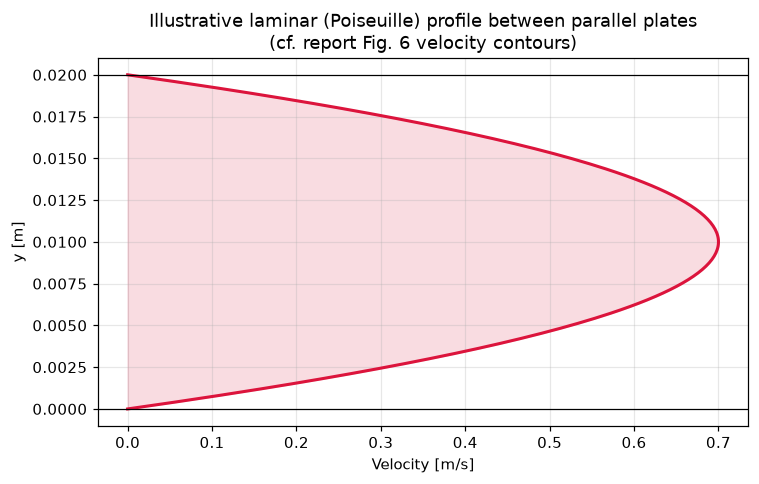

In [8]:
y_channel = np.linspace(0, 0.02, 200)   # channel gap, matching Fig. 6 (0-0.02 m)
u_max = 0.7                              # m/s, peak velocity from report Fig. 6
h = 0.02 / 2
u = u_max * (1 - ((y_channel - h) / h) ** 2)   # parabolic (Poiseuille) profile

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(u, y_channel, color="crimson", lw=2)
ax.fill_betweenx(y_channel, 0, u, alpha=0.15, color="crimson")
ax.set_xlabel("Velocity [m/s]")
ax.set_ylabel("y [m]")
ax.set_title("Illustrative laminar (Poiseuille) profile between parallel plates\n(cf. report Fig. 6 velocity contours)")
ax.axhline(0, color="k", lw=0.8)
ax.axhline(0.02, color="k", lw=0.8)
plt.tight_layout()
plt.show()

## Chapter 7 — The Combined Brayton–Rankine Power Cycle

Reactor-outlet helium at 950 °C first drives a **Helium Brayton cycle** (primary loop), whose exhaust
still carries enough energy to raise steam for a **Steam Rankine cycle** (secondary loop) — a
bottoming cycle that both generates extra electricity *and* provides the specific steam quality MED
desalination needs (Chapter 9). This is the full primary/secondary thermodynamic state-point table
(report Appendix A, Table 9):

In [9]:
state_points = pd.DataFrame([
    ["Primary (He)", 1, "Compressor inlet", 30, 105.0, 43, -205.1],
    ["Primary (He)", 2, "Compressor outlet", 350, 105.0, 70, None],
    ["Primary (He)", 3, "Reactor outlet", 950, 105.0, 70, 300.0],
    ["Primary (He)", 4, "Gas turbine exit", 650, 105.0, 45, 147.4],
    ["Primary (He)", 5, "HR system inlet", 399, 105.0, 44, -195.0],
    ["Primary (He)", 6, "HR system outlet", 30, 105.0, 43, -47.3],
    ["Secondary (H2O)", "A", "Feedwater pump out", 70, 12.5, 70, -0.12],
    ["Secondary (H2O)", "B", "Steam turbine in", 500, 12.5, 70, 195.0],
    ["Secondary (H2O)", "C", "Steam turbine out", 70, 12.5, 0.31, 12.1],
    ["Secondary (H2O)", "D", "Desalination in", 70, 12.5, 0.31, 182.8],
], columns=["Loop", "Pt.", "Component", "T [C]", "mdot [kg/s]", "P [bar]", "Power/Heat [MW]"])
state_points

,Loop,Pt.,Component,T [C],mdot [kg/s],P [bar],Power/Heat [MW]
0,Primary (He),1,Compressor inlet,30,105.0,43.00,-205.10
1,Primary (He),2,Compressor outlet,350,105.0,70.00,NaN
2,Primary (He),3,Reactor outlet,950,105.0,70.00,300.00
3,Primary (He),4,Gas turbine exit,650,105.0,45.00,147.40
4,Primary (He),5,HR system inlet,399,105.0,44.00,-195.00
5,Primary (He),6,HR system outlet,30,105.0,43.00,-47.30
6,Secondary (H2O),A,Feedwater pump out,70,12.5,70.00,-0.12
7,Secondary (H2O),B,Steam turbine in,500,12.5,70.00,195.00
8,Secondary (H2O),C,Steam turbine out,70,12.5,0.31,12.10
9,Secondary (H2O),D,Desalination in,70,12.5,0.31,182.80


**Governing work/heat-balance equations** (report §3.2):

$$W_{helium,turb} = \dot{m}_{He}\int_{T_{out}}^{T_{in}} C_p(T)\,dT = \dot{m}_{He}(h_{in}-h_{out})$$
$$W_{comp} = \dot{m}_{He}(h_{out}-h_{in})$$
$$\dot{m}_{He}(h_{He,in}-h_{He,out}) = \dot{m}_{water}(h_{steam,out}-h_{water,in}) \qquad\text{(HRSG energy balance)}$$
$$W_{steam,turb} = \dot{m}_{steam}(h_{in}-h_{out})\,\eta_{thermal}$$

Note $C_p(T)$, not a constant — this is exactly why `src/htgr_physics.py`'s module docstring
(§1.4 of the report) insists on CoolProp for the helium property lookups, rather than the ideal-gas
constant-$C_p$ assumption Simulink defaults to.

Comparing the individual and combined cycles by their Carnot bound $\eta = 1 - T_{min}/T_{max}$
shows exactly why a *combined* cycle is worth the added complexity:

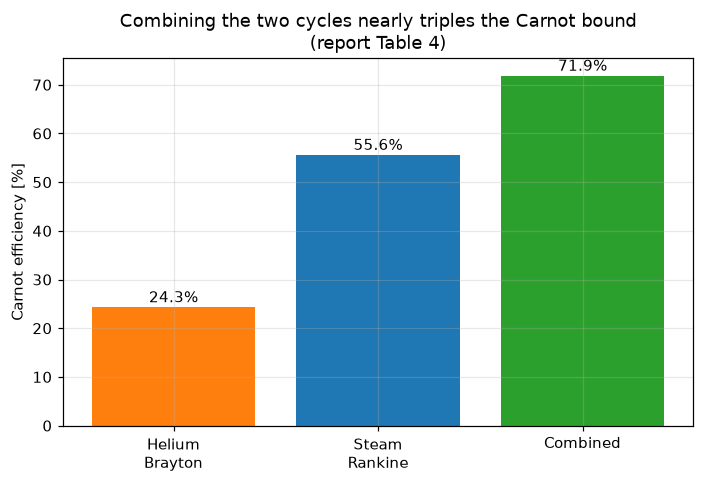

In [10]:
cycles = pd.DataFrame({
    "Cycle": ["Helium Brayton", "Steam Rankine", "Combined"],
    "T_max [K]": [1220, 773, 1220],
    "T_min [K]": [923, 343, 343],
})
cycles["Carnot efficiency"] = 1 - cycles["T_min [K]"] / cycles["T_max [K]"]
cycles["Carnot efficiency"] = cycles["Carnot efficiency"].map(lambda x: f"{x:.1%}")
cycles

fig, ax = plt.subplots(figsize=(6.5, 4.5))
vals = (1 - np.array([923, 343, 343]) / np.array([1220, 773, 1220])) * 100
ax.bar(["Helium\nBrayton", "Steam\nRankine", "Combined"], vals,
       color=["tab:orange", "tab:blue", "tab:green"])
for i, v in enumerate(vals):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")
ax.set_ylabel("Carnot efficiency [%]")
ax.set_title("Combining the two cycles nearly triples the Carnot bound\n(report Table 4)")
plt.tight_layout()
plt.show()

The combined cycle's Carnot efficiency (~72%) isn't achieved in practice — it's the
thermodynamic *ceiling*. What it demonstrates is *why* pairing a high-$T_{max}$ topping cycle with a
low-$T_{min}$ bottoming cycle beats either alone: the combined cycle spans the full 343–1220 K range,
where a single cycle is stuck spanning a much narrower slice of it.

**Energy Utilisation Factor (EUF)** captures the same idea from a cogeneration angle — crediting
*useful heat* (sent to desalination) alongside electricity, not just electrical output:

$$\text{EUF} = \frac{\dot{W}_{elec} + \dot{Q}_{useful}}{\dot{Q}_{fuel}}$$

This is what makes cogeneration fundamentally more efficient than buying grid electricity and
burning separate fuel for heat: the report's presentation (§5.3) shows a textbook CHP comparison
where a conventional split (50 units to a 40%-efficient power station + 50 units to an 80%-efficient
boiler, from 100 units of fuel) needs only 67 units of fuel to deliver the *same* 20 units
electricity + 40 units heat when generated as combined heat and power instead.

---
# Part III — Hybrid Desalination and Economics

## Chapter 8 — Heat Recovery Steam Generation: Bridging the Two Loops

The Heat Recovery Steam Generator (HRSG) is the physical component realising the HRSG energy-balance
equation above: helium exiting the gas turbine at 650 °C (state point 4) transfers heat into the
secondary water/steam loop, producing the 500 °C, 70 bar steam that enters the steam turbine (state
point B). This is exactly the chain `src/data_pipeline.py` continues computationally — its
`helium_turbine_work()` function (a Python/CoolProp port of the report's `helium_turbine.m`) picks up
right where this chapter's state-point table leaves off, turning the reactor-outlet gas state into a
turbine work estimate for every one of the 1,000 Monte Carlo scenarios.

## Chapter 9 — Multi-Effect Desalination with Thermal Vapour Compression

Low-pressure steam leaving the steam turbine (state point C, 70 °C) still carries 182.8 MW of useful
heat (state point D) — too low-grade for further power extraction, but exactly right for driving
Multi-Effect Distillation (MED). The **Gain Output Ratio (GOR)** measures how many kilograms of
freshwater are produced per kilogram of driving steam — a GOR > 1 is only possible because each
"effect" reuses the latent heat released by the previous effect's condensing vapour.

In [11]:
# Worked example, reproduced exactly from report Sec. 3.4 / presentation Sec. 7.1
P_thermal = 300e6      # W (300 MWth)
t_day = 86_400          # s/day
m_steam = 12.5           # kg/s
GOR = 11.1                # within the report's stated 10-12 range

m_steam_day = m_steam * t_day
print(f"Step 1 - total steam input per day:      {m_steam_day:,.0f} kg/day")

V_water_kg = m_steam_day * GOR
print(f"Step 2 - theoretical water output (GOR={GOR}): {V_water_kg:,.0f} kg/day")

rho_water = 1000.0  # kg/m3
V_vol = V_water_kg / rho_water
print(f"Step 3 - volumetric conversion:          {V_vol:,.0f} m3/day")

eta_avail = 0.95
V_actual = V_vol * eta_avail
print(f"Step 4 - at {eta_avail:.0%} availability factor:  {V_actual:,.0f} m3/day  <- matches report's 11,400 m3/day")

Step 1 - total steam input per day:      1,080,000 kg/day
Step 2 - theoretical water output (GOR=11.1): 11,988,000 kg/day
Step 3 - volumetric conversion:          11,988 m3/day
Step 4 - at 95% availability factor:  11,389 m3/day  <- matches report's 11,400 m3/day


**Why this matters for population served.** At roughly 140–150 L/person/day of municipal water
use, ~11,400 m³/day comfortably serves the report's target of 80,000 people, with headroom — which is
the population-demand justification from Chapter 1 for scaling to 300 MWth in the first place.

## Chapter 10 — Economic Modelling with DEEP

The IAEA's **Desalination Economic Evaluation Program (DEEP)** was used as the economic modelling
tool — this notebook presents its outputs as reported, rather than re-deriving the underlying
cash-flow/IRR model, since that model itself isn't part of the given source material.

In [12]:
deep_summary = pd.DataFrame({
    "Metric": ["Levelized Capital Cost", "Levelized Operating Cost", "Power Cost",
               "Thermal Utilization", "IRR", "Payback Period", "CAPEX", "Water Cost (60-yr lifecycle)"],
    "Combined Cycle + Hybrid Desalination": ["$0.33/m3", "-$1.21/m3", "$50.8/MWh",
                                              "60%", "27%", "4.3 years", "$1.5 billion", "$1.50/m3"],
})
deep_summary

,Metric,Combined Cycle + Hybrid Desalination
0,Levelized Capital Cost,$0.33/m3
1,Levelized Operating Cost,-$1.21/m3
2,Power Cost,$50.8/MWh
3,Thermal Utilization,60%
4,IRR,27%
5,Payback Period,4.3 years
6,CAPEX,$1.5 billion
7,Water Cost (60-yr lifecycle),$1.50/m3


The **negative** levelized operating cost (-$1.21/m³) is not a typo — it reflects that reclaiming
673 °C thermal exergy that would otherwise be rejected as waste heat is credited as an *operating
saving* relative to a baseline gas-fired plant, per the report's "Economic Decoupling" framing
(§3.3): once the $1.5B CAPEX is committed, water cost is largely insulated from fuel-price
volatility, unlike a conventional gas-fired desalination plant.

The CAPEX breakdown shows why: Heat (37.1%) and Annualised Capital (32.2%) dominate the water price,
while Fuel is a mere 3.5% — the inverse of a gas-fired plant's cost structure, where fuel typically
dominates.

## Chapter 11 — Sustainability: Quantifying the CO₂ Offset

With water and power output established, the environmental case follows directly by comparing
against fossil-fuel baselines: 5 kg CO₂ per m³ for conventional thermal desalination, and
0.74 t CO₂/MWh for grid electricity.

Desalination:  4,161,000 m3/yr x 5 kg/m3 = 20,805 t CO2/yr
Electricity:   332,880 MWh/yr x 0.74 t/MWh = 246,331 t CO2/yr

Total annual CO2 avoided: 267,136 t CO2/yr  <- matches report's 267,136 t/yr
Over a 30-year lifespan:  ~8.0 million tonnes CO2 avoided  <- matches report's ~8M tonnes


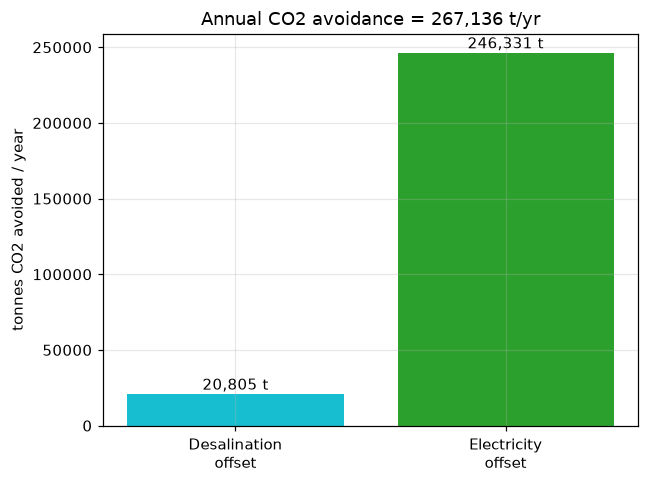

In [13]:
# Desalination offset
V_water_yr = 12_000 * 0.95 * 365          # m3/year
E_desal = V_water_yr * 5 / 1000            # tonnes CO2/year (5 kg/m3 -> tonnes)
print(f"Desalination:  {V_water_yr:,.0f} m3/yr x 5 kg/m3 = {E_desal:,.0f} t CO2/yr")

# Electricity offset
capacity_MWe = 40
W_elec_yr = capacity_MWe * 0.95 * 8_760    # MWh/year
E_elec = W_elec_yr * 0.74                   # tonnes CO2/year
print(f"Electricity:   {W_elec_yr:,.0f} MWh/yr x 0.74 t/MWh = {E_elec:,.0f} t CO2/yr")

E_total = E_desal + E_elec
print(f"\nTotal annual CO2 avoided: {E_total:,.0f} t CO2/yr  <- matches report's 267,136 t/yr")
print(f"Over a 30-year lifespan:  ~{E_total*30/1e6:.1f} million tonnes CO2 avoided  <- matches report's ~8M tonnes")

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(["Desalination\noffset", "Electricity\noffset"], [E_desal, E_elec],
       color=["tab:cyan", "tab:green"])
ax.set_ylabel("tonnes CO2 avoided / year")
ax.set_title(f"Annual CO2 avoidance = {E_total:,.0f} t/yr")
for i, v in enumerate([E_desal, E_elec]):
    ax.text(i, v + 3000, f"{v:,.0f} t", ha="center")
plt.tight_layout()
plt.show()

Electricity generation dominates the CO₂ offset (~92% of the total) — the desalination process
itself is comparatively low-carbon even against a fossil baseline, because MED's energy demand is
mostly *low-grade heat* (which this design gets for free from the turbine exhaust) rather than
high-grade electricity.

---
# Part IV — Reactor and Plant Safety

## Chapter 12 — Reactor and Plant Safety Systems

Four layered safety mechanisms, as presented in the project's final presentation (§8.1):

| # | Mechanism | Purpose |
|:---:|---|---|
| 1 | **Process control (PID)** | Manages thermal inertia so that even during a turbine trip, core temperature stays within the graphite matrix's safe structural limits |
| 2 | **Feedback and master loops** | Automatic shutdown at 90% prompt criticality, preventing meltdown scenarios |
| 3 | **Variable helium pump rate** | Dynamic mass-flow control (adjusting the 105 kg/s baseline) lets the plant follow demand load without thermally shocking the HRSG |
| 4 | **Secondary-loop barrier** | An intermediate heat exchanger means the water supplying 80,000 people is never in direct contact with the radioactive primary helium coolant |

Mechanism 2 — automatic shutdown at 90% prompt criticality — is the real-world control system this
project's `HTGRAgent` (see [`src/ml_surrogate.py`](../src/ml_surrogate.py) and the
[ML deep-dive in the README](../README.md#mathematical-deep-dive-ml-surrogate--htgragent)) is a
software analogue of: both are automated systems that continuously check an operating point against
a hard physical limit and intervene — the reactor's own control system on reactivity margin, the
software agent on predicted peak fuel temperature — before a threshold is crossed.

Mechanism 3 is also precisely what Chapter 3's thermal-core equations model: the $2\dot{m}C_p(T_c -
T_{in})$ convective-removal term is the coolant flow rate the presentation describes being varied
for load-following.

---
# Part V — Independent Water Heat Rejection System

Everything so far accounts for heat that becomes useful work or freshwater. What's left over —
147.7 MWth in this design — still has to go somewhere, and in an arid siting where consumptive wet
cooling towers would undermine the entire point of desalinating water, it has to leave via air or a
closed water loop only.

## Chapter 13 — Design Down-Selection

Four heat-rejection architectures were scored on a weighted Pugh matrix against six criteria:

In [14]:
criteria = ["Parasitic load", "Heat transfer coeff.", "Footprint", "Safety", "Maintenance", "Cost"]
weights = np.array([0.25, 0.25, 0.20, 0.15, 0.10, 0.05])
scores = pd.DataFrame({
    "Air Cond.":       [2, 3, 2, 4, 3, 3],
    "Double-Pipe HE":  [4, 2, 3, 4, 4, 4],
    "Shell-&-Tube HE": [3, 4, 2, 5, 3, 3],
    "Porous Cube":     [4, 5, 5, 3, 2, 2],
}, index=criteria)

totals = scores.T.dot(weights)
scores.loc["Weighted total"] = totals.round(2)
scores

,Air Cond.,Double-Pipe HE,Shell-&-Tube HE,Porous Cube
Parasitic load,2.0,4.0,3.00,4.0
Heat transfer coeff.,3.0,2.0,4.00,5.0
Footprint,2.0,3.0,2.00,5.0
Safety,4.0,4.0,5.00,3.0
Maintenance,3.0,4.0,3.00,2.0
Cost,3.0,4.0,3.00,2.0
Weighted total,2.7,3.3,3.35,4.0


The **Porous Cube** design wins on the strength of its footprint and heat-transfer-coefficient
scores — a porous metal matrix has an enormous internal surface area per unit volume ("volumetric
condensation"), at the cost of manufacturability and difficulty quantifying porous-media parameters
(density, permeability) precisely — exactly the trade-off the report's literature review (§2) flags.

**Final architecture** (three heat-exchange stages, each isolating the radioactive primary loop
further from the ambient environment):

$$\text{Helium (primary)} \;\xrightarrow{\text{shell-\&-tube}}\; \text{Water/steam} \;\xrightarrow{\text{porous Al + thermosyphon}}\; \text{Water vapour} \;\xrightarrow{\text{air-cooled condenser}}\; \text{Ambient air}$$

The middle stage's thermosyphon (a sealed two-phase device relying on gravity-driven density
differences between liquid and vapour) is what eliminates a pump for the steam side entirely — a
direct parasitic-load saving baked into the physical design, not a control-system optimisation.

## Chapter 14 — Modelling the Heat Rejection System

### Condensate loop pump (Darcy–Weisbach)

$$\dot{V} = \frac{\dot{m}}{\rho} \qquad A = \frac{\dot{V}}{v} \qquad D = \sqrt{\frac{4A}{\pi}}$$
$$h_m = \frac{(\sum K)\,v^2}{2g} \qquad h_f = f\frac{L}{D}\frac{v^2}{2g} \qquad H = h_f + h_m \qquad P_{pump} = \frac{\rho g \dot{V} H}{\eta}$$

In [15]:
# Reproduced exactly from report Sec. 3.2 assumptions
V_dot = 0.0623      # m3/s
v = 3.0               # m/s
rho_w = 1000.0
g = 9.81
f = 0.0156            # Darcy friction factor (Swamee-Jain)
L = 30.0               # m
eta_pump = 0.75

A = V_dot / v
D = np.sqrt(4 * A / np.pi)

# NOTE: the report's itemized fittings (6 x 0.45 elbows + 2 x 0.15 gate valves + 1 x 2.0 check
# valve) sum to 5.0, but the report's own headline value and downstream result (h_m = 2.98 m)
# only reproduce using SUM_K = 6.5. Using 6.5 here to match the report's stated result -
# flagging the itemized-vs-headline mismatch rather than silently picking one.
sum_K_itemized = 6 * 0.45 + 2 * 0.15 + 1 * 2.0
sum_K_report = 6.5
print(f"Itemized fitting K-sum = {sum_K_itemized:.2f}   (report states SUM_K = {sum_K_report} -- discrepancy noted)")

h_m = sum_K_report * v**2 / (2 * g)
h_f = f * (L / D) * v**2 / (2 * g)
H = h_f + h_m
P_pump = rho_w * g * V_dot * H / eta_pump

print(f"\nA = {A:.5f} m2   D = {D:.5f} m")
print(f"h_f = {h_f:.3f} m   h_m = {h_m:.3f} m   H = {H:.3f} m")
print(f"P_pump = {P_pump/1000:.2f} kW   <- matches report's 3.51 kW")

Itemized fitting K-sum = 5.00   (report states SUM_K = 6.5 -- discrepancy noted)

A = 0.02077 m2   D = 0.16261 m
h_f = 1.320 m   h_m = 2.982 m   H = 4.302 m
P_pump = 3.51 kW   <- matches report's 3.51 kW


### Dry-cooler air-side sizing

$$Q_{mod} = \dot{m}_{air}\,C_p\,\Delta T \qquad Q_{eff} = \frac{Q_{mod}}{1.10} \qquad N_{mod} = \left\lceil\frac{Q_{total}}{Q_{eff}}\right\rceil \qquad P_{fan} = \frac{\Delta P_{air}\,\dot{V}_{total}}{\eta_{fan}}$$

using the Kelvion RF-NC101E4H dry-cooler module's manufacturer data (surface area 197.1 m²,
airflow 19,400 m³/h, dimensions 2220×1610×1350 mm).

In [16]:
# Constants from report Appendix D (Kelvion module + team design assumptions)
rho_air, cp_air, dT_air = 1.177, 1005.0, 15.0     # kg/m3, J/kg-K, K
Vdot_air_mod = 19_400 / 3600                        # m3/s
crosswind_multiplier = 1.10
Q_total = 147.7e6                                    # W, baseline heat rejection duty
dP_air, eta_fan = 225.0, 0.65                        # Pa, -

mdot_air_mod = rho_air * Vdot_air_mod
Q_cap_mod = mdot_air_mod * cp_air * dT_air
Q_cap_eff = Q_cap_mod / crosswind_multiplier
N_mod = int(np.ceil(Q_total / Q_cap_eff))

Vdot_total = Vdot_air_mod * N_mod
P_fan = dP_air * Vdot_total / eta_fan

print(f"Air energy capacity per module: {Q_cap_mod/1e3:.1f} kW (before crosswind) -> {Q_cap_eff/1e3:.1f} kW (effective)")
print(f"Modules required: {N_mod}   <- matches report's 1,700")
print(f"Total airflow: {Vdot_total:,.0f} m3/s")
print(f"Fan power: {P_fan/1e6:.3f} MW   <- matches report's 3.17 MW total parasitic load")

# Footprint - independent verification
mod_L, mod_W = 2.220, 1.610   # m (plan-view footprint; height 1.350 m is vertical)
footprint = mod_L * mod_W * N_mod
print(f"\nFootprint (independently computed): {footprint:,.0f} m2")
print("Report Table 8 states 60,214 m2; the presentation slide states 6,021.4 m2.")
print("This computation (~6,076 m2) agrees with the PRESENTATION's figure, suggesting the")
print("report's Table 8 value has a misplaced decimal point (10x too large) - flagged, not silently picked.")

Air energy capacity per module: 95.6 kW (before crosswind) -> 86.9 kW (effective)
Modules required: 1700   <- matches report's 1,700
Total airflow: 9,161 m3/s
Fan power: 3.171 MW   <- matches report's 3.17 MW total parasitic load

Footprint (independently computed): 6,076 m2
Report Table 8 states 60,214 m2; the presentation slide states 6,021.4 m2.
This computation (~6,076 m2) agrees with the PRESENTATION's figure, suggesting the
report's Table 8 value has a misplaced decimal point (10x too large) - flagged, not silently picked.


## Chapter 15 — Heat Rejection Results, Validation, and Future Directions

### Headline figures of merit

In [17]:
hr_results = pd.DataFrame({
    "Metric": ["Heat rejected", "Total parasitic load", "Parasitic load per MWth rejected",
               "Number of modules", "Footprint (this notebook's calc)"],
    "Value": ["147.7 MWth", "3.17 MW", "21.5 kW", "1,700", "~6,076 m2"],
})
hr_results

,Metric,Value
0,Heat rejected,147.7 MWth
1,Total parasitic load,3.17 MW
2,Parasitic load per MWth rejected,21.5 kW
3,Number of modules,"1,700"
4,Footprint (this notebook's calc),"~6,076 m2"


### Validation against industry benchmarks

Industry trends put parasitic load for water-independent air-cooled heat rejection at 4–6% of power
output. This design's 21.5 kW per MWth rejected is **2.15%** of power output — inside the same order
of magnitude, and notably *better* than the industry range, which the report attributes to the porous
cube's much higher effective heat-transfer area allowing a smaller, less parasitic-load-hungry
system for the same duty.

### An emerging alternative worth flagging: radiative cooling panels

The report's discussion section (§5.2) evaluates passive radiative sky cooling as a potential
complement. Its total heat flux balances four terms:

$$q''_{total} = q''_{rad}(T_s) + q''_{a}(T_a) + q''_{solar} + q''_{conv}$$

In [18]:
radiative = pd.DataFrame({
    "Heat flux [W/m2]": ["q''_rad", "q''_a", "q''_solar", "q''_conv", "q''_total"],
    "Best case": ["629.0 (unchanged)", "218.9 (January)", "0 (night)", "1536 (windy)", "1947"],
    "Worst case": ["629.0 (unchanged)", "369.7 (July)", "96.4 (daytime)", "0 (no wind)", "162.9"],
    "Typical day": ["629.0 (unchanged)", "~350 (warm summer)", "48.2 (day avg)", "774 (min. avg wind)", "1004.8"],
})
radiative

,Heat flux [W/m2],Best case,Worst case,Typical day
0,q''_rad,629.0 (unchanged),629.0 (unchanged),629.0 (unchanged)
1,q''_a,218.9 (January),369.7 (July),~350 (warm summer)
2,q''_solar,0 (night),96.4 (daytime),48.2 (day avg)
3,q''_conv,1536 (windy),0 (no wind),774 (min. avg wind)
4,q''_total,1947,162.9,1004.8


The headline number is striking: a parasitic load of essentially **zero** (0.000208 as a fraction
of MWth rejected — pump-only, no fans) — but achieving the same 147.7 MWth duty with panels lying
flat (no stacking) would require roughly **53,200 m²** of panel area, an order of magnitude more
footprint than the porous-cube design, and the technology is heavily wind-dependent. The report's own
verdict: *"a very promising emerging heat rejection technology"* worth further investigation, not
(yet) a replacement for the porous-cube baseline.

---
# Part VI — System Integration and Conclusions

## Chapter 16 — Bringing It All Together

The full plant is a single chain, each chapter above handing its output to the next:

```mermaid
flowchart LR
    A["Ch.2-3: Point kinetics<br/>+ 3-node thermal core<br/>300 MWth"] --> B["Ch.6: Coolant channel<br/>fluid mechanics"]
    B --> C["Ch.7: Helium Brayton<br/>primary loop"]
    C --> D["Ch.8: HRSG"]
    D --> E["Ch.7: Steam Rankine<br/>secondary loop"]
    E --> F["Ch.9: MED + TVC<br/>desalination"]
    C --> G["Ch.13-15: Independent<br/>water heat rejection"]
    F --> H["Ch.10-11: Economics<br/>+ CO2 offset"]
    A --> I["Ch.12: Safety systems<br/>(PID, 90% prompt-crit. shutdown)"]
```

This notebook has walked the *engineering* chain top to bottom. The rest of this repository walks
the same chain *computationally*: [`src/htgr_physics.py`](../src/htgr_physics.py) implements
Chapters 2–4 as a tested, coupled ODE system; [`src/data_pipeline.py`](../src/data_pipeline.py)
extends that into Chapters 7–8's turbine work via 1,000 Monte Carlo operating points; and
[`src/ml_surrogate.py`](../src/ml_surrogate.py)'s `HTGRAgent` operationalises Chapter 12's safety
philosophy — checking a candidate operating point against a hard limit before it's accepted — as a
scalable, probabilistic software system rather than a single hard-coded PID loop.

## Chapter 17 — Conclusions and Further Work

**What this system achieves, end to end:**
- A 300 MWth HTGR, scaled 10× from the real HTTR to serve 80,000 people/day with freshwater and
  30–50 MWe of electricity, at a 950 °C outlet temperature chosen specifically for high-GOR MED.
- A combined Brayton–Rankine power cycle reaching a 72% Carnot ceiling — nearly triple either cycle
  alone — feeding both grid electricity and MED-grade process heat from the same fuel input.
- 11,400 m³/day of freshwater at GOR = 11.1, economically viable at 27% IRR / 4.3-year payback,
  decoupled from fossil-fuel price volatility.
- 267,136 tonnes CO₂/year avoided (~8 million tonnes over a 30-year lifespan), driven mostly by
  displaced grid electricity generation.
- A water-independent heat-rejection system handling the remaining 147.7 MWth at 21.5 kW/MWth
  parasitic load — inside industry benchmarks, on a porous-metal thermosyphon architecture chosen
  over four alternatives by a weighted Pugh matrix.

**Documented limitations and future work**, stated by the source material and preserved here rather
than smoothed over:
- Controller (PID) tuning is not yet optimised — the fuel/moderator oscillation in Chapter 4/5's
  transient response is attributed to this, not to the energy-balance equations themselves.
- Thermosyphon internal heat-transfer coefficients (Chapter 14) are conservative placeholders pending
  manufacturer performance curves, not first-principles calculations.
- Radiative cooling panels (Chapter 15) remain a promising but underdeveloped complement, gated on
  reducing their footprint and wind dependency.
- Two source-document numerical discrepancies were independently resolved during this notebook's
  construction (the heat-rejection pump's fitting-loss coefficient, and the footprint figure's likely
  misplaced decimal point) — flagged explicitly above rather than silently reconciled.
